# Patrizia De Camillis 
# Data Visualisation and Insight

# Import Libraries

In [1]:
#Import libraries

import pandas as pd
import json
import missingno as msno
import geopandas as gpd

# Import Datasets

In [2]:
url = "http://data.insideairbnb.com/ireland/leinster/dublin/2025-09-16/data/listings.csv.gz"
url2 = "http://data.insideairbnb.com/ireland/leinster/dublin/2025-09-16/data/reviews.csv.gz"

listings_large = pd.read_csv(url)
reviews = pd.read_csv(url2)

# EDA

In [3]:
#increase column viewed

pd.set_option('display.max_columns', 500)

In [4]:
#Show first 5 rows

reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...
1,44077,211369,2011-03-28,444004,Solidea,We have been here 4 nights. Stay in a home is ...
2,44077,234215,2011-04-21,465058,Michael And Isabelle,Teresa and Hughie were great hosts. They were ...
3,44077,261843,2011-05-13,490005,Weston,"No surprises, was as described. Very gracious..."
4,44077,268148,2011-05-17,520460,Barbara,"Teresa was a lovely hostess, and we had a deli..."


In [5]:
#Look at first 5 rows

listings_large.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44077,https://www.airbnb.com/rooms/44077,20250916040708,2025-09-16,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,https://www.airbnb.com/users/show/193005,Teresa,2010-08-06,"Dublin, Ireland","I am a friendly outgoing Irishwoman ,who love...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/2167f...,https://a0.muscache.com/im/pictures/user/2167f...,Churchtown,2.0,2.0,"['email', 'phone']",t,t,"Churchtown, Ireland",Dn Laoghaire-Rathdown,NaN,53.29178,-6.25792,Private room in bungalow,Private room,2,1.0,1 private bath,1.0,2.0,"[""Paid washer \u2013 In unit"", ""Wine glasses"",...",$86.00,3,30,3.0,3.0,30.0,30.0,3.0,30.0,NaN,t,6,9,9,9,2025-09-16,394,37,5,9,42,222,19092.0,2011-03-20,2025-09-13,4.82,4.86,4.77,4.93,4.93,4.68,4.83,NaN,f,2,0,2,0,2.23
1,85156,https://www.airbnb.com/rooms/85156,20250916040708,2025-09-16,previous scrape,Cosy Comfortable Irish Cottage 1 Double Bed,Our Cottage is a charming light filled cottage...,"I love Dundrum and its surrounding areas ,<br ...",https://a0.muscache.com/pictures/1749253/9ed2a...,193005,https://www.airbnb.com/users/show/193005,Teresa,2010-08-06,"Dublin, Ireland","I am a friendly outgoing Irishwoman ,who love...",within an hour,100%,97%,t,https://a0.muscache.com/im/pictures/user/2167f...,https://a0.muscache.com/im/pictures/user/2167f...,Churchtown,2.0,2.0,"['email', 'phone']",t,t,"Churchtown, Ireland",Dn Laoghaire-Rathdown,NaN,53.29209,-6.25624,Private room in bungalow,Private room,2,NaN,1.5 baths,NaN,NaN,"[""Wine glasses"", ""Coffee maker"", ""Coffee"", ""Sh...",NaN,3,21,3.0,3.0,21.0,21.0,3.0,21.0,NaN,t,7,7,7,7,2025-09-16,357,41,5,7,41,246,NaN,2011-05-24,2025-09-14,4.81,4.84,4.75,4.91,4.89,4.64,4.77,NaN,f,2,0,2,0,2.05
2,159889,https://www.airbnb.com/rooms/159889,20250916040708,2025-09-16,city scrape,Friendly Single Room,Washing can be done at a cost of €5 per load....,Plenty of buses into the city and the area is ...,https://a0.muscache.com/pictures/3031697/a8259...,766611,https://www.airbnb.com/users/show/766611,Marie,2011-07-01,"Dublin Airport, Ireland",Used to host students and now I am looking fo...,within a few hours,70%,91%,f,https://a0.muscache.com/im/pictures/user/5059e...,https://a0.muscache.com/im/pictures/user/5059e...,Beaumont,3.0,3.0,"['email', 'phone']",t,t,"Dublin, Ireland",Dublin City,NaN,53.39027,-6.23547,Private room in home,Private room,1,2.0,2 shared baths,1.0,1.0,"[""Private patio or balcony"", ""Paid washer"", "

In [6]:
#Show column headers

listings_large.columns

Index(['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name',
       'description', 'neighborhood_overview', 'picture_url', 'host_id',
       'host_url', 'host_name', 'host_since', 'host_location', 'host_about',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_thumbnail_url', 'host_picture_url',
       'host_neighbourhood', 'host_listings_count',
       'host_total_listings_count', 'host_verifications',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude',
       'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms',
       'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
       'maximum_minimum_nights', 'minimum_maximum_nights',
       'maximum_maximum_nights', 'minimum_nights_avg_ntm',
       'maximum_nights_avg_ntm', 'ca

In [7]:
#Create new df
#include only columns of interest

listings = listings_large[['id', 'neighbourhood_cleansed',
       'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews','property_type']].copy()

In [8]:
#look at first 5 rows

listings.head()

,id,neighbourhood_cleansed,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,property_type
0,44077,Dn Laoghaire-Rathdown,53.29178,-6.25792,Private room,$86.00,3,394,Private room in bungalow
1,85156,Dn Laoghaire-Rathdown,53.29209,-6.25624,Private room,NaN,3,357,Private room in bungalow
2,159889,Dublin City,53.39027,-6.23547,Private room,$48.00,2,464,Private room in home
3,162809,Dn Laoghaire-Rathdown,53.28326,-6.19188,Private room,$101.00,2,397,Private room in townhouse
4,237465,Dublin City,53.39558,-6.17524,Entire home/apt,NaN,1,599,Entire rental unit


In [9]:
#show unique values per column
#there are 6945 rows and id has 6945 unique values, each row is an individual listing, no listings are duplicated

listings.nunique()

id                        6945
neighbourhood_cleansed       4
latitude                  5999
longitude                 6252
room_type                    4
price                      597
minimum_nights              49
number_of_reviews          432
property_type               54
dtype: int64

In [10]:
#Show total columns and rows

listings.shape

(6945, 9)

In [11]:
#Detail on rows, null values and data types

listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6945 entries, 0 to 6944
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      6945 non-null   int64  
 1   neighbourhood_cleansed  6945 non-null   object 
 2   latitude                6945 non-null   float64
 3   longitude               6945 non-null   float64
 4   room_type               6945 non-null   object 
 5   price                   5244 non-null   object 
 6   minimum_nights          6945 non-null   int64  
 7   number_of_reviews       6945 non-null   int64  
 8   property_type           6945 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 488.4+ KB


<Axes: >

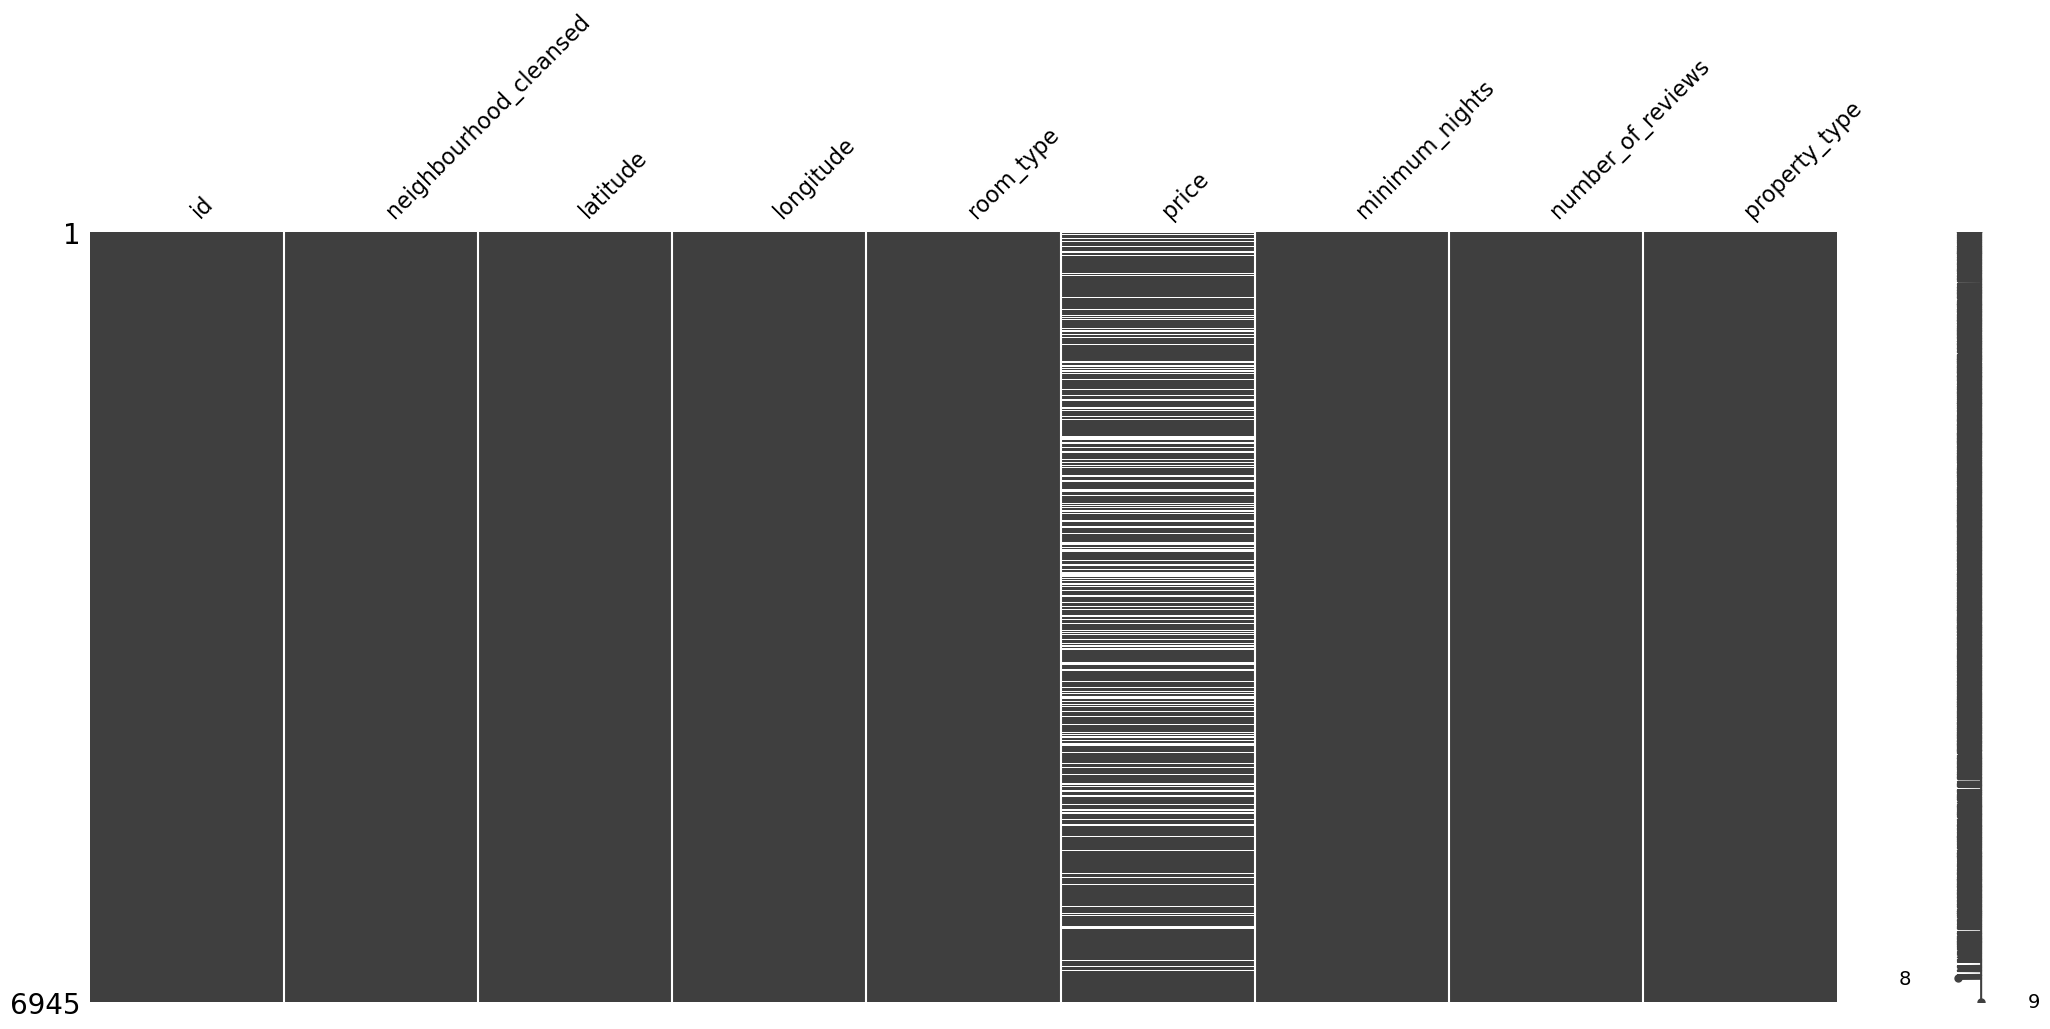

In [12]:
#visual representation of null values

msno.matrix(listings)

In [13]:
#Remove character and convert to float
#the price has a dollar sign and is stored as string (object)
#python can't perform maths on string

listings['price'] = (
    listings['price']
    .replace('[\$,]', '', regex=True) #remove symbols using regex
    .astype(float)                    #covert to float
)

In [14]:
# Rename column headers

listings = listings.rename(columns={"neighbourhood_cleansed": "neighbourhood"})

In [15]:
#value score

listings["value_score"] = listings["number_of_reviews"] / listings["price"]

In [16]:
#remove all null rows before getting top 50 reviews
#plotly map doesn't work with any null values

listings = listings.dropna()

In [17]:
#look at top 50 reviews
# I used number of reviews to assume which listings were occupied more than others

top50 = listings.nlargest(50, "number_of_reviews").reset_index(drop=True)

In [18]:
#sort top 50 by number of reviews

top50 = top50.sort_values(by="number_of_reviews", ascending=False)

In [19]:
#get id's of top 50

top50_ids = top50["id"]

In [20]:
#filter reviews using id's above to only include top 50 listings

top50_reviews = reviews[reviews["listing_id"].isin(top50_ids)].copy()

In [21]:
#show unique values per column
#confirms that reviews are only for 50 listings now

top50_reviews.nunique()

listing_id          50
id               35895
date              4308
reviewer_id      34734
reviewer_name     8699
comments         35304
dtype: int64

In [22]:
#check top 50 reviews for null values

top50_reviews.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35895 entries, 3523 to 197843
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   listing_id     35895 non-null  int64 
 1   id             35895 non-null  int64 
 2   date           35895 non-null  object
 3   reviewer_id    35895 non-null  int64 
 4   reviewer_name  35895 non-null  object
 5   comments       35889 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.9+ MB


In [23]:
#remove null values
#reviews dataframe not used in maps, still removing null values to avoid any other issues

top50_reviews = top50_reviews.dropna()

In [24]:
#convert date/time to format suitable for time series

top50_reviews["date"] = pd.to_datetime(top50_reviews["date"])

In [25]:
# Convert to weekly time series (number of reviews per week)
#better format for time series

weekly_reviews = (
    top50_reviews
    .set_index("date")                 #set date as index
    .resample("W")                     #resample by week
    .size()                            #count reviews per week
    .rolling(4).mean()                 #average of last 4 weeks
    .reset_index(name="review_count")  #convert back to dataframe
)

In [26]:
#look at dataframe

weekly_reviews

,date,review_count
0,2012-05-06,NaN
1,2012-05-13,NaN
2,2012-05-20,NaN
3,2012-05-27,0.75
4,2012-06-03,1.00
...,...,...
694,2025-08-24,118.50
695,2025-08-31,114.00
696,2025-09-07,95.00
697,2025-09-14,79.00


In [27]:
#drop null values

weekly_reviews = weekly_reviews.dropna()

In [28]:
#save cleaned dataframes

file = r"C:\Users\decamilp\VSCode\DataVisualisation\listings.csv"
file3 = r"C:\Users\decamilp\VSCode\DataVisualisation\weekly_reviews.csv"

top50.to_csv(file, index=False)
weekly_reviews.to_csv(file3, index=False)

In [29]:
top50.head()

,id,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,property_type,value_score
0,46256758,Dublin City,53.346674,-6.263992,Entire home/apt,252.0,1,1879,Entire serviced apartment,7.456349
1,14941430,Dublin City,53.359340,-6.258470,Entire home/apt,92.0,1,1122,Entire townhouse,12.195652
2,46389088,Dublin City,53.348492,-6.230111,Entire home/apt,218.0,1,1097,Entire serviced apartment,5.032110
3,17688731,Fingal,53.453210,-6.223990,Entire home/apt,100.0,1,980,Entire cabin,9.800000
4,13759408,Dublin City,53.396370,-6.211200,Private room,68.0,1,894,Private room in home,13.147059
